# Tahap 1 — Membangun Case Base (IMPROVED)

Notebook ini mengeksekusi Tahap 1 dari pipeline **Case-Based Reasoning (CBR)** untuk analisis putusan pengadilan perceraian.

### Perbaikan pada versi ini:
1. **Character Reconstruction** — Mendeteksi dan memfilter baris karakter tunggal dari watermark/sidebar PDF Mahkamah Agung
2. **Boilerplate Removal** — Menghapus disclaimer berulang, header/footer halaman
3. **Regex yang Lebih Aman** — Tidak merusak istilah hukum penting
4. **Custom Legal Stopwords** — Stopwords khusus domain hukum
5. **Protected Stemming** — Stemming yang tidak merusak istilah kunci
6. **Quality Validation** — Peringatan jika teks hasil cleaning tidak berkualitas

## 1. Import dan Instalasi Library

In [1]:
!pip install pdfplumber pdfminer.six Sastrawi nltk pandas numpy matplotlib seaborn tqdm

import os
import re
import glob
import pandas as pd
import numpy as np
import pdfplumber
import nltk
from tqdm import tqdm
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from collections import Counter
from nltk.corpus import stopwords

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("Semua library berhasil diimpor!")


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


Semua library berhasil diimpor!


## 2. Membuat Struktur Folder Project

In [2]:
base_path = "../"
directories = [
    "data/raw_pdf",
    "data/raw",
    "data/processed",
    "data/eval",
    "data/results",
    "logs",
    "models"
]

for dir_path in directories:
    full_path = os.path.join(base_path, dir_path)
    os.makedirs(full_path, exist_ok=True)
    print(f"Direktori siap: {full_path}")

Direktori siap: ../data/raw_pdf
Direktori siap: ../data/raw
Direktori siap: ../data/processed
Direktori siap: ../data/eval
Direktori siap: ../data/results
Direktori siap: ../logs
Direktori siap: ../models


## 3. Ekstraksi PDF ke Plain Text

Membaca semua file PDF di `/data/raw_pdf/` dan mengekstrak teksnya.

In [3]:
raw_pdf_dir = os.path.join(base_path, "data/raw_pdf")
raw_txt_dir = os.path.join(base_path, "data/raw")

pdf_files = sorted(glob.glob(os.path.join(raw_pdf_dir, "*.pdf")))
print(f"Ditemukan {len(pdf_files)} file PDF untuk diproses.\n")

for idx, pdf_path in enumerate(tqdm(pdf_files, desc="Ekstraksi PDF")):
    filename = os.path.basename(pdf_path)
    case_id = f"case_{idx+1:03d}"
    txt_filename = f"{case_id}.txt"
    txt_path = os.path.join(raw_txt_dir, txt_filename)
    
    full_text = ""
    total_pages = 0
    try:
        with pdfplumber.open(pdf_path) as pdf:
            total_pages = len(pdf.pages)
            for page in pdf.pages:
                text = page.extract_text()
                if text:
                    full_text += text + "\n"
                    
        with open(txt_path, "w", encoding="utf-8") as f:
            f.write(full_text)
            
        print(f"[{case_id}] Sukses: {filename} | Halaman: {total_pages} | Karakter: {len(full_text)}")
    except Exception as e:
        print(f"[{case_id}] GAGAL mengekstrak {filename}: {e}")

Ditemukan 45 file PDF untuk diproses.




Ekstraksi PDF:   0%|          | 0/45 [00:00<?, ?it/s]


Ekstraksi PDF:   2%|▏         | 1/45 [00:02<01:44,  2.36s/it]

[case_001] Sukses: putusan_0003_pdt.g_2011_pa.srl_20260530072648.pdf | Halaman: 23 | Karakter: 56874



Ekstraksi PDF:   4%|▍         | 2/45 [00:05<01:58,  2.76s/it]

...


Ekstraksi PDF:  98%|█████████▊| 44/45 [01:17<00:01,  1.71s/it]

[case_044] Sukses: putusan_673_pdt.g_2016_pa.clg_20260530081945.pdf | Halaman: 6 | Karakter: 17196



Ekstraksi PDF: 100%|██████████| 45/45 [01:19<00:00,  1.60s/it]


Ekstraksi PDF: 100%|██████████| 45/45 [01:19<00:00,  1.76s/it]

[case_045] Sukses: putusan_729_pdt.g_2019_pa.tgr_20260530075015.pdf | Halaman: 9 | Karakter: 26873


## 4. Fungsi Rekonstruksi Teks PDF (IMPROVED)

### Masalah Kritis:
PDF dari website Mahkamah Agung memiliki **watermark/sidebar** yang menyebabkan `pdfplumber` mengekstrak setiap huruf watermark pada baris terpisah (`a\ni\ns\ne\n...`).

### Solusi:
1. **Filter baris pendek** (≤ 3 karakter) — ini adalah noise dari watermark sidebar
2. **Hapus boilerplate berulang** (Disclaimer, header halaman, URL)
3. **Gabungkan baris konten** yang valid menjadi teks utuh

In [4]:
def reconstruct_text(raw_text):
    """
    Merekonstruksi teks yang terfragmentasi dari PDF Mahkamah Agung.
    Menghapus noise watermark sidebar dan boilerplate berulang.
    """
    lines = raw_text.split('\n')
    clean_lines = []
    
    # Pattern boilerplate yang harus dihapus
    boilerplate_patterns = [
        r'^Disclaimer$',
        r'^Kepaniteraan Mahkamah Agun',
        r'^pelaksanaan fungsi peradilan',
        r'^D Em al a am',
        r'^putusan\.mahkamahagung\.go\.id',
        r'^Hal\.?\s*\d+\s*dari\s*\d+',
        r'^Halaman\s*\d+',
        r'^Put\.?\s*No\.',
        r'^Direktori Putusan Mahkamah Agung',
        r'^mahkamahagung\.go\.id',
    ]
    boilerplate_re = [re.compile(p, re.IGNORECASE) for p in boilerplate_patterns]
    
    for line in lines:
        stripped = line.strip()
        
        # 1. Skip baris kosong
        if not stripped:
            continue
        
        # 2. Skip baris yang terlalu pendek (watermark sidebar: 1-3 karakter)
        if len(stripped) <= 3:
            continue
        
        # 3. Skip baris boilerplate
        is_boilerplate = False
        for pattern in boilerplate_re:
            if pattern.search(stripped):
                is_boilerplate = True
                break
        if is_boilerplate:
            continue
        
        # 4. Bersihkan karakter sidebar yang menempel di awal/akhir baris
        # Pattern: huruf tunggal + spasi di awal baris (misal: 'gDEMI' -> 'DEMI')
        stripped = re.sub(r'^[a-zA-Z]\s(?=[A-Z])', '', stripped)
        # Pattern: huruf tunggal yang menempel di akhir kata terakhir
        stripped = re.sub(r'(?<=[a-z])[A-Z]$', '', stripped)
        # Pattern: huruf tunggal yang menempel di akhir baris setelah spasi  
        stripped = re.sub(r'\s+[a-z]$', '', stripped)
        
        if stripped and len(stripped) > 3:
            clean_lines.append(stripped)
    
    # Gabungkan semua baris konten menjadi satu teks utuh
    reconstructed = ' '.join(clean_lines)
    
    # Bersihkan spasi berlebih
    reconstructed = re.sub(r'\s+', ' ', reconstructed).strip()
    
    return reconstructed

# Tes rekonstruksi pada satu file
test_file = os.path.join(raw_txt_dir, "case_001.txt")
if os.path.exists(test_file):
    with open(test_file, 'r', encoding='utf-8') as f:
        raw = f.read()
    reconstructed = reconstruct_text(raw)
    print(f"Raw text length: {len(raw)}")
    print(f"Reconstructed length: {len(reconstructed)}")
    print(f"\nSampel teks (500 karakter pertama):")
    print(reconstructed[:500])
else:
    print("File test tidak ditemukan. Jalankan sel ekstraksi PDF terlebih dahulu.")

Raw text length: 56874
Reconstructed length: 28743

Sampel teks (500 karakter pertama):
P U T U S A N Nomor: 033/Pdt.G/2011/PA.Srl BISMILLAHIRRAHMANIRRAHIM gDEMI KEADILAN BERDASARKAN KETUHANAN YANG MAHA ESAd Pengadilan Agama Sarolangun yang m emeriksa dan mengadili perkara tertentu pada tingkat pertama dalam persidangan majelis telah menjatuhkan putusan sebagai berikut dalam perkara cerai gugat antara: PENGGUGAT, umur 26 taheun, agama Islam, pekerjaan Tani, a pendidRikan SD, tempat tinggal di KABUPATEN SARO LANGUN, sebagai Penggugat ; MELAWAN TERGUGAT, umur 30 tahun, agama Islam, p


## 5. Text Cleaning / Preprocessing (IMPROVED)

### Perbaikan:
- **Rekonstruksi karakter** terlebih dahulu sebelum cleaning
- **Legal stopwords** yang komprehensif
- **Protected stemming** dengan cache
- **Regex yang aman** untuk domain hukum

In [5]:
# Inisialisasi Sastrawi Stemmer dengan Cache
factory = StemmerFactory()
stemmer = factory.create_stemmer()
stem_cache = {}

# Stopwords Indonesia + Custom Legal Stopwords
stop_words_id = set(stopwords.words('indonesian'))

# Stopwords khusus domain hukum (kata yang muncul di SEMUA putusan, tidak informatif)
custom_legal_stopwords = {
    # Institusi & prosedural
    'pengadilan', 'hakim', 'perkara', 'putusan', 'republik', 'indonesia',
    'agama', 'mahkamah', 'agung', 'direktori', 'majelis', 'sidang',
    'panitera', 'ketua', 'anggota', 'pengganti',
    # Kata hubung & partikel berulang
    'bahwa', 'yang', 'dan', 'di', 'dari', 'pada', 'untuk', 'dengan',
    'ini', 'itu', 'adalah', 'oleh', 'kepada', 'sebagai', 'tersebut',
    'telah', 'akan', 'dapat', 'dalam', 'atau', 'juga', 'serta',
    'maka', 'atas', 'tentang', 'antara', 'sesuai', 'berdasarkan',
    # Boilerplate hukum
    'disclaimer', 'halaman', 'nomor', 'tanggal', 'ttd',
    # Kata yang terlalu umum
    'ada', 'tidak', 'sudah', 'belum', 'bisa', 'harus', 'masih',
    'sangat', 'sedang', 'seperti', 'saat', 'setelah', 'sebelum'
}
stop_words_id.update(custom_legal_stopwords)

def clean_text(raw_text):
    """
    Pipeline preprocessing teks putusan yang lebih aman.
    """
    # A. Rekonstruksi teks (hapus noise watermark/sidebar)
    text = reconstruct_text(raw_text)
    
    # B. Lowercase
    text = text.lower()
    
    # C. Hapus URL
    text = re.sub(r'http[s]?://\S+', '', text)
    text = re.sub(r'\S+\.go\.id\S*', '', text)
    
    # D. Hapus nomor halaman berulang
    text = re.sub(r'hal\.?\s*\d+\s*dari\s*\d+\s*(?:put|hal)\.?[^.]*', '', text)
    
    # E. Hapus angka dan karakter spesial (pertahankan huruf dan spasi)
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # F. Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    
    # G. Tokenisasi
    tokens = text.split()  # simple split lebih aman daripada word_tokenize untuk teks yang sudah bersih
    
    # H. Filter token terlalu pendek (sisa noise) dan stopword
    tokens = [w for w in tokens if len(w) > 1 and w not in stop_words_id]
    
    # I. Stemming dengan cache
    stemmed_tokens = []
    for token in tokens:
        if token not in stem_cache:
            stem_cache[token] = stemmer.stem(token)
        stemmed = stem_cache[token]
        # Hanya masukkan token yang masih punya panjang > 1 setelah stemming
        if len(stemmed) > 1:
            stemmed_tokens.append(stemmed)
    
    return ' '.join(stemmed_tokens)

print("Fungsi cleaning teks (IMPROVED) siap!")
print(f"Total stopwords: {len(stop_words_id)}")

Fungsi cleaning teks (IMPROVED) siap!
Total stopwords: 780


## 6. Validasi Kualitas Cleaning

Sebelum memproses semua file, uji kualitas cleaning pada satu dokumen.

In [6]:
# Tes cleaning pada satu file
test_file = os.path.join(raw_txt_dir, "case_001.txt")
if os.path.exists(test_file):
    with open(test_file, 'r', encoding='utf-8') as f:
        raw = f.read()
    
    clean = clean_text(raw)
    tokens = clean.split()
    
    # Hitung proporsi huruf tunggal (indikator noise)
    single_chars = [t for t in tokens if len(t) == 1]
    pct_single = len(single_chars) / len(tokens) * 100 if tokens else 0
    
    print(f"Panjang teks mentah: {len(raw)} karakter")
    print(f"Panjang teks bersih: {len(clean)} karakter")
    print(f"Jumlah token: {len(tokens)}")
    print(f"Token huruf tunggal: {len(single_chars)} ({pct_single:.1f}%)")
    print()
    
    if pct_single > 10:
        print("[WARNING] Terlalu banyak huruf tunggal! Cleaning mungkin belum optimal.")
    else:
        print("[OK] Kualitas cleaning terlihat baik.")
    
    print(f"\nSampel teks bersih (300 karakter pertama):")
    print(clean[:300])
    print(f"\n\n20 token pertama:")
    print(tokens[:20])
else:
    print("Jalankan sel ekstraksi PDF terlebih dahulu.")

Panjang teks mentah: 56874 karakter
Panjang teks bersih: 12414 karakter
Jumlah token: 1903
Token huruf tunggal: 0 (0.0%)

[OK] Kualitas cleaning terlihat baik.

Sampel teks bersih (300 karakter pertama):
pdt pa srl bismillahirrahmanirrahim gdemi adil tuhan maha esad sarolangun emeriksa adil tingkat sidang jatuh cerai gugat gugat umur taheun islam kerja tani pendidrikan sd tinggal kabupaten saro langun gugat lawan gugat umur islam kerja tani didik sd tinggal kabudpaten sarolangun dniketahui alamat di


20 token pertama:
['pdt', 'pa', 'srl', 'bismillahirrahmanirrahim', 'gdemi', 'adil', 'tuhan', 'maha', 'esad', 'sarolangun', 'emeriksa', 'adil', 'tingkat', 'sidang', 'jatuh', 'cerai', 'gugat', 'gugat', 'umur', 'taheun']


## 7. Proses Cleaning Seluruh Dokumen

Membaca file raw `.txt`, memproses dengan `clean_text()`, memvalidasi, dan menyimpan hasilnya.

In [7]:
log_path = os.path.join(base_path, "logs/cleaning.log")
logging.basicConfig(filename=log_path, level=logging.INFO, 
                    format='%(asctime)s - %(levelname)s - %(message)s', force=True)

txt_files = sorted(glob.glob(os.path.join(raw_txt_dir, "*.txt")))
processed_dir = os.path.join(base_path, "data/processed")

dataset_records = []
quality_issues = []

for txt_path in tqdm(txt_files, desc="Cleaning & Validasi"):
    filename = os.path.basename(txt_path)
    case_id = filename.replace('.txt', '')
    
    with open(txt_path, "r", encoding="utf-8") as f:
        raw_text = f.read()
        
    raw_length = len(raw_text)
    
    # Validasi dokumen kosong
    if raw_length < 100:
        msg = f"Teks terlalu pendek ({raw_length} char) untuk {filename}."
        logging.warning(msg)
        print(f"\n[WARNING] {msg}")
        continue
        
    clean_txt = clean_text(raw_text)
    clean_length = len(clean_txt)
    tokens = clean_txt.split()
    
    # Validasi kualitas
    single_chars = [t for t in tokens if len(t) == 1]
    pct_single = len(single_chars) / len(tokens) * 100 if tokens else 100
    
    if pct_single > 15:
        msg = f"[QUALITY] {filename}: {pct_single:.1f}% huruf tunggal - mungkin masih ada noise"
        logging.warning(msg)
        quality_issues.append(msg)
    
    if clean_length < 200:
        msg = f"[QUALITY] {filename}: Teks bersih terlalu pendek ({clean_length} karakter)"
        logging.warning(msg)
        quality_issues.append(msg)
    else:
        logging.info(f"Sukses cleaning {filename}. {raw_length} -> {clean_length} chars, {len(tokens)} tokens.")
        
    # Simpan File Bersih
    clean_filename = f"{case_id}_clean.txt"
    clean_filepath = os.path.join(processed_dir, clean_filename)
    with open(clean_filepath, "w", encoding="utf-8") as f:
        f.write(clean_txt)
        
    dataset_records.append({
        "case_id": case_id,
        "original_length": raw_length,
        "clean_text": clean_txt,
        "text_length": clean_length,
        "token_count": len(tokens),
        "single_char_pct": round(pct_single, 1)
    })

print(f"\nProses selesai! {len(dataset_records)} dokumen berhasil diproses.")
print(f"Log tersimpan di: {log_path}")

if quality_issues:
    print(f"\n[PERHATIAN] {len(quality_issues)} dokumen dengan potensi masalah kualitas:")
    for issue in quality_issues:
        print(f"  - {issue}")


Cleaning & Validasi:   0%|          | 0/45 [00:00<?, ?it/s]


Cleaning & Validasi:   4%|▍         | 2/45 [00:43<15:38, 21.84s/it]


Cleaning & Validasi:   7%|▋         | 3/45 [01:05<15:25, 22.04s/it]


Cleaning & Validasi:   9%|▉         | 4/45 [01:31<15:49, 23.15s/it]


Cleaning & Validasi:  11%|█         | 5/45 [01:54<15:24, 23.11s/it]

...


Cleaning & Validasi:  96%|█████████▌| 43/45 [13:57<00:33, 16.75s/it]


Cleaning & Validasi:  98%|█████████▊| 44/45 [14:07<00:14, 14.82s/it]


Cleaning & Validasi: 100%|██████████| 45/45 [14:22<00:00, 14.78s/it]


Cleaning & Validasi: 100%|██████████| 45/45 [14:22<00:00, 19.16s/it]


Proses selesai! 45 dokumen berhasil diproses.
Log tersimpan di: ../logs/cleaning.log


## 8. Membuat Dataset CSV

In [8]:
df_cases = pd.DataFrame(dataset_records)
csv_path = os.path.join(processed_dir, "cases_clean.csv")

if not df_cases.empty:
    df_cases.to_csv(csv_path, index=False, encoding="utf-8")
    print(f"Dataset berhasil disimpan ke {csv_path} dengan total {len(df_cases)} dokumen.")
else:
    print("Dataset kosong, tidak ada data yang bisa disimpan.")

# Tampilkan sampel (khusus kolom non-teks untuk readability)
print("\nRingkasan Dataset:")
display_cols = ['case_id', 'original_length', 'text_length', 'token_count', 'single_char_pct']
print(df_cases[display_cols].head())

# Verifikasi kualitas: tampilkan sampel teks
print("\n--- Sampel Teks Bersih (case_001, 200 karakter pertama) ---")
if len(df_cases) > 0:
    print(df_cases.iloc[0]['clean_text'][:200])

Dataset berhasil disimpan ke ../data/processed\cases_clean.csv dengan total 45 dokumen.

Ringkasan Dataset:
    case_id  original_length  text_length  token_count  single_char_pct
0  case_001            56874        12414         1903              0.0
1  case_002            54888        15895         2487              0.0
2  case_003            25141         6136          928              0.0
3  case_004            49205        10554         1681              0.0
4  case_005            40680         9920         1514              0.0

--- Sampel Teks Bersih (case_001, 200 karakter pertama) ---
pdt pa srl bismillahirrahmanirrahim gdemi adil tuhan maha esad sarolangun emeriksa adil tingkat sidang jatuh cerai gugat gugat umur taheun islam kerja tani pendidrikan sd tinggal kabupaten saro langun


## 9. Analisis & Visualisasi Data

=== Analisis Dataset ===
Jumlah total dokumen: 45
Rata-rata panjang dokumen bersih: 9401 karakter
Rata-rata token per dokumen: 1450 token
Rata-rata single char %: 0.0%
Jumlah kata unik (Vocabulary): 6987


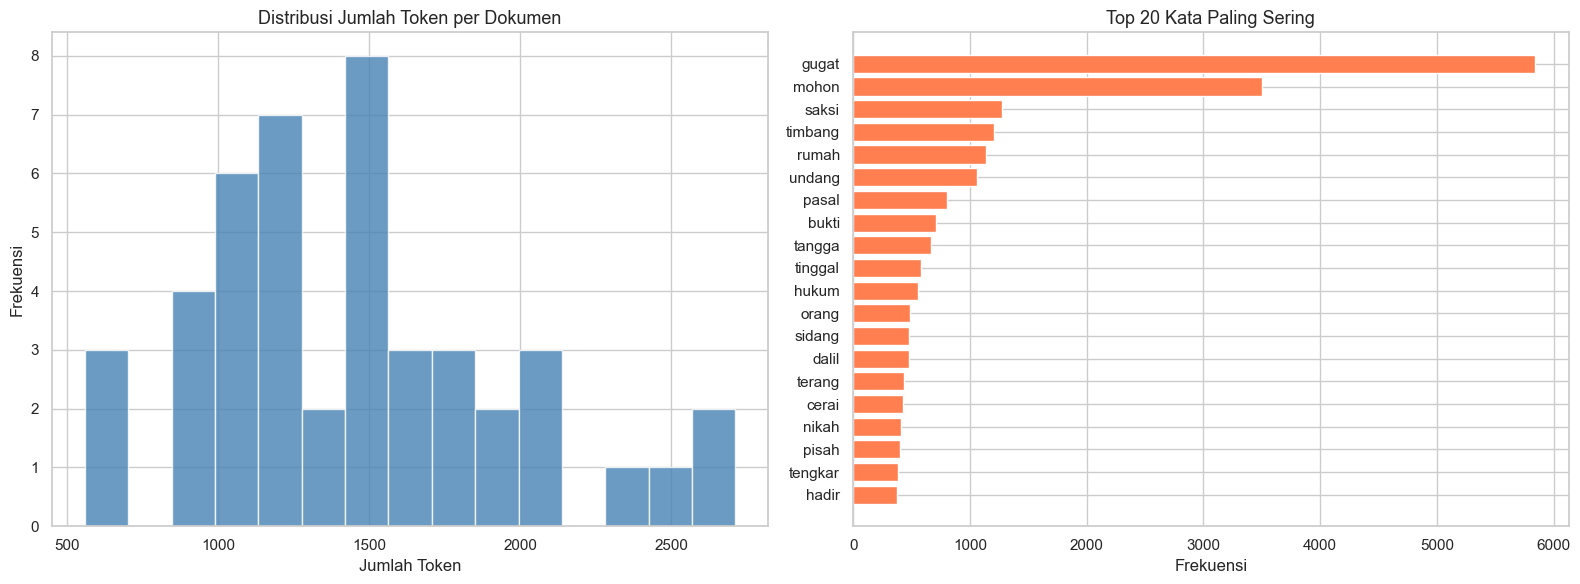


Tahap 1 (Membangun Case Base) — SELESAI!


In [9]:
print("=== Analisis Dataset ===")
print(f"Jumlah total dokumen: {len(df_cases)}")
print(f"Rata-rata panjang dokumen bersih: {df_cases['text_length'].mean():.0f} karakter")
print(f"Rata-rata token per dokumen: {df_cases['token_count'].mean():.0f} token")
print(f"Rata-rata single char %: {df_cases['single_char_pct'].mean():.1f}%")

# Kumpulkan semua token untuk analisis vocabulary
all_tokens = []
for text in df_cases['clean_text']:
    all_tokens.extend(text.split())

# Filter huruf tunggal dari analisis
all_tokens = [t for t in all_tokens if len(t) > 1]
word_freq = Counter(all_tokens)

print(f"Jumlah kata unik (Vocabulary): {len(word_freq)}")

# Plot
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribusi panjang dokumen
axes[0].hist(df_cases['token_count'], bins=15, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribusi Jumlah Token per Dokumen', fontsize=13)
axes[0].set_xlabel('Jumlah Token')
axes[0].set_ylabel('Frekuensi')

# Top 20 kata terbanyak
top_20 = word_freq.most_common(20)
words, counts = zip(*top_20) if top_20 else ([], [])
axes[1].barh(list(reversed(words)), list(reversed(counts)), color='coral')
axes[1].set_title('Top 20 Kata Paling Sering', fontsize=13)
axes[1].set_xlabel('Frekuensi')

plt.tight_layout()
plt.savefig(os.path.join(base_path, 'data/processed/preprocessing_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nTahap 1 (Membangun Case Base) — SELESAI!")